In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os
from datetime import datetime
import folium
import gpxpy
import pandas as pd
from pathlib import Path
from folium.plugins import HeatMap
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
# Set the style for the plots
plt.style.use('ggplot')
sns.set_style("whitegrid")

In [2]:
import xml.etree.ElementTree as ET

def parse_gpx(file_path):
    tree = ET.parse(file_path)
    root = tree.getroot()

    # namespace (critical!)
    ns = {"gpx": "http://www.topografix.com/GPX/1/0"}

    records = []

    for pt in root.findall(".//gpx:trkpt", ns):
        lat = float(pt.attrib["lat"])
        lon = float(pt.attrib["lon"])

        time_elem = pt.find("gpx:time", ns)
        time = time_elem.text if time_elem is not None else None

        records.append((lat, lon, time))

    if not records:
        return pd.DataFrame()

    df = pd.DataFrame(records, columns=["lat", "lon", "time"])
    df["time"] = pd.to_datetime(df["time"], errors="coerce")
    df["trajectory_id"] = Path(file_path).stem

    return df


In [3]:
folder = Path("londres_traces_walking")

dfs = []
for file in folder.glob("*.gpx"):
    dfi = parse_gpx(file)
    dfs.append(dfi)

df = pd.concat(dfs, ignore_index=True)

In [14]:
df

,lat,lon,time,trajectory_id
0,51.573279,-0.071939,2023-09-28 14:50:00+00:00,trace_001b5c2c-8084-4f02-b4f7-c66f7c55d0de
1,51.573204,-0.071963,2023-09-28 14:50:00+00:00,trace_001b5c2c-8084-4f02-b4f7-c66f7c55d0de
2,51.573205,-0.071951,2023-09-28 14:50:00+00:00,trace_001b5c2c-8084-4f02-b4f7-c66f7c55d0de
3,51.573204,-0.071941,2023-09-28 14:50:00+00:00,trace_001b5c2c-8084-4f02-b4f7-c66f7c55d0de
4,51.573202,-0.071934,2023-09-28 14:50:00+00:00,trace_001b5c2c-8084-4f02-b4f7-c66f7c55d0de
...,...,...,...,...
4151773,51.310861,0.231053,2014-08-27 15:07:41+00:00,trace_fff0cb23-7466-4964-9df3-b3b75c42bfc4
4151774,51.310854,0.231050,2014-08-27 15:07:42+00:00,trace_fff0cb23-7466-4964-9df3-b3b75c42bfc4
4151775,51.310829,0.231037,2014-08-27 15:07:44+00:00,trace_fff0cb23-7466-4964-9df3-b3b75c42bfc4
4151776,51.310807,0.231022,2014-08-27 15:07:46+00:00,trace_fff0cb23-7466-4964-9df3-b3b75c42bfc4


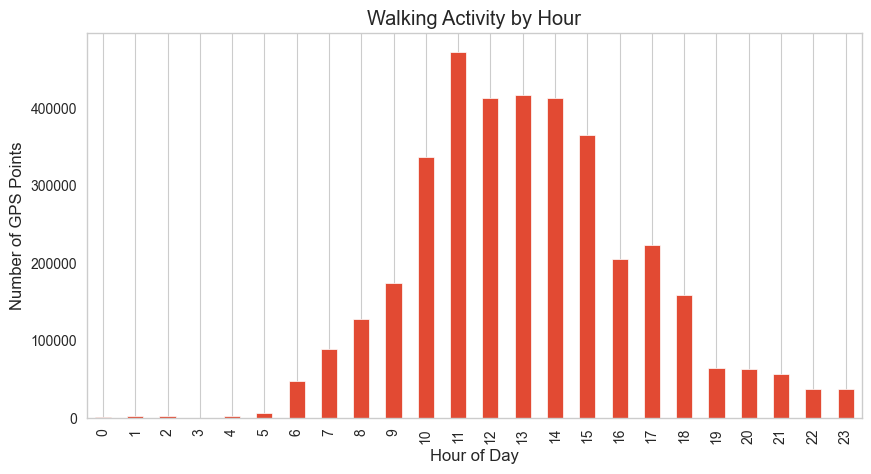

In [4]:
df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind='bar')

plt.xlabel("Hour of Day")
plt.ylabel("Number of GPS Points")
plt.title("Walking Activity by Hour")
plt.xticks(range(24))
plt.grid(axis='y')

plt.show()

In [5]:
from astral import Observer
from astral.sun import elevation

observer = Observer(latitude=51.5, longitude=-0.12)
def is_night(dt):
    elev = elevation(observer, dt)
    return elev < -12  # nautical twilight threshold

In [6]:
def classify_daylight(night_ratio, night_threshold=0.8, day_threshold=0.2):
    """
    night_ratio: proportion of points in nautical night (0.0 → fully day, 1.0 → fully night)
    
    Returns 'night', 'day', or 'mixed' based on thresholds.
    """
    if night_ratio >= night_threshold:
        return "night"
    elif night_ratio <= day_threshold:
        return "day"
    else:
        return "mixed"
traj_night = {}

for traj_id, group in df.groupby('trajectory_id'):
    times = group['time']

    # proportion of points in nautical night
    night_ratio = times.apply(is_night).mean()

    traj_night[traj_id] = night_ratio
df_traj = pd.DataFrame({
    "trajectory_id": list(traj_night.keys()),
    "night_ratio": list(traj_night.values())
})

df_traj['time_of_day'] = df_traj["night_ratio"].apply(classify_daylight)
df = df.merge(df_traj[['trajectory_id','time_of_day']], on='trajectory_id', how='left')
df

,lat,lon,time,trajectory_id,hour,time_of_day
0,51.538571,-0.198133,2015-01-26 12:41:56+00:00,trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f,12,day
1,51.538556,-0.198121,2015-01-26 12:41:58+00:00,trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f,12,day
2,51.538517,-0.198154,2015-01-26 12:42:02+00:00,trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f,12,day
3,51.538499,-0.198185,2015-01-26 12:42:04+00:00,trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f,12,day
4,51.538489,-0.198197,2015-01-26 12:42:05+00:00,trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f,12,day
...,...,...,...,...,...,...
3726748,51.536364,-0.191316,2011-01-03 13:39:53+00:00,trace_fffcc03d-709e-4c33-9b40-b6834e847851,13,day
3726749,51.536304,-0.191260,2011-01-03 13:39:59+00:00,trace_fffcc03d-709e-4c33-9b40-b6834e847851,13,day
3726750,51.536279,-0.191174,2011-01-03 13:40:03+00:00,trace_fffcc03d-709e-4c33-9b40-b6834e847851,13,day
3726751,51.536256,-0.191041,2011-01-03 13:40:12+00:00,trace_fffcc03d-709e-4c33-9b40-b6834e847851,13,day


In [7]:
df.drop_duplicates(subset='trajectory_id')['time_of_day'].value_counts(normalize=True)

time_of_day
day      0.941046
night    0.054977
mixed    0.003977
Name: proportion, dtype: float64

In [8]:
df['trajectory_id'].nunique()

8549

PARIS


In [9]:
folder = Path("paris_traces_walking")

dfs = []
for file in folder.glob("*.gpx"):
    dfi = parse_gpx(file)
    dfs.append(dfi)

df = pd.concat(dfs, ignore_index=True)

In [4]:
df

,lat,lon,time,trajectory_id
0,48.894534,2.305758,2022-09-29 12:06:00+00:00,trace_002809c3-6124-4b39-8396-eeb4b0c7d0e7
1,48.894539,2.305766,2022-09-29 12:06:00+00:00,trace_002809c3-6124-4b39-8396-eeb4b0c7d0e7
2,48.894542,2.305772,2022-09-29 12:06:00+00:00,trace_002809c3-6124-4b39-8396-eeb4b0c7d0e7
3,48.894546,2.305780,2022-09-29 12:06:00+00:00,trace_002809c3-6124-4b39-8396-eeb4b0c7d0e7
4,48.894551,2.305788,2022-09-29 12:06:00+00:00,trace_002809c3-6124-4b39-8396-eeb4b0c7d0e7
...,...,...,...,...
544973,48.826117,2.345614,2012-08-23 15:47:35+00:00,trace_ffcf5def-7e62-4258-b689-9875d77c0b7a
544974,48.826127,2.345712,2012-08-23 15:47:39+00:00,trace_ffcf5def-7e62-4258-b689-9875d77c0b7a
544975,48.826094,2.345791,2012-08-23 15:47:46+00:00,trace_ffcf5def-7e62-4258-b689-9875d77c0b7a
544976,48.826030,2.345837,2012-08-23 15:47:48+00:00,trace_ffcf5def-7e62-4258-b689-9875d77c0b7a


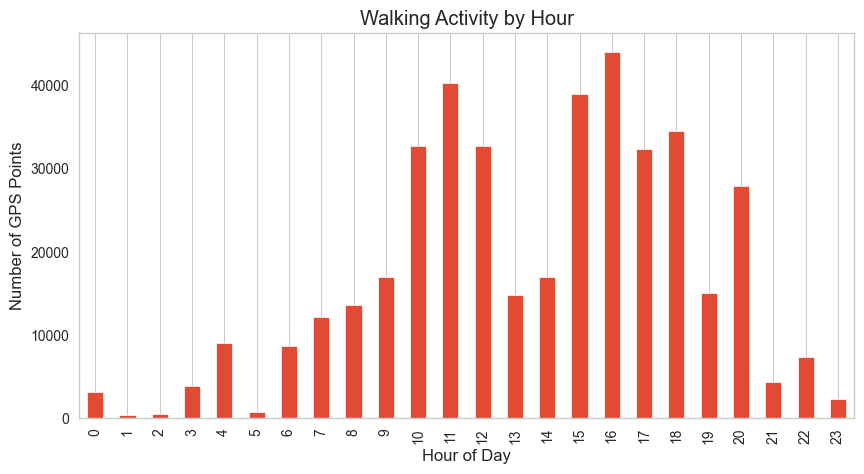

In [10]:
df['time'] = pd.to_datetime(df['time'])
df['hour'] = df['time'].dt.hour
hour_counts = df['hour'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind='bar')

plt.xlabel("Hour of Day")
plt.ylabel("Number of GPS Points")
plt.title("Walking Activity by Hour")
plt.xticks(range(24))
plt.grid(axis='y')

plt.show()

In [11]:
from astral import Observer
from astral.sun import elevation

observer = Observer(latitude=48.85, longitude=2.35)
def is_night(dt):
    elev = elevation(observer, dt)
    return elev < -12  # nautical twilight threshold

In [12]:
def classify_daylight(night_ratio, night_threshold=0.8, day_threshold=0.2):
    """
    night_ratio: proportion of points in nautical night (0.0 → fully day, 1.0 → fully night)
    
    Returns 'night', 'day', or 'mixed' based on thresholds.
    """
    if night_ratio >= night_threshold:
        return "night"
    elif night_ratio <= day_threshold:
        return "day"
    else:
        return "mixed"
traj_night = {}

for traj_id, group in df.groupby('trajectory_id'):
    times = group['time']

    # proportion of points in nautical night
    night_ratio = times.apply(is_night).mean()

    traj_night[traj_id] = night_ratio
df_traj = pd.DataFrame({
    "trajectory_id": list(traj_night.keys()),
    "night_ratio": list(traj_night.values())
})

df_traj['time_of_day'] = df_traj["night_ratio"].apply(classify_daylight)
df = df.merge(df_traj[['trajectory_id','time_of_day']], on='trajectory_id', how='left')
df

,lat,lon,time,trajectory_id,hour,time_of_day
0,48.842347,2.367164,2010-04-17 09:59:47+00:00,trace_004d417a-6786-43f8-bcab-bf869cf0d1f0,9,day
1,48.842356,2.367150,2010-04-17 09:59:48+00:00,trace_004d417a-6786-43f8-bcab-bf869cf0d1f0,9,day
2,48.842366,2.367136,2010-04-17 09:59:49+00:00,trace_004d417a-6786-43f8-bcab-bf869cf0d1f0,9,day
3,48.842375,2.367122,2010-04-17 09:59:50+00:00,trace_004d417a-6786-43f8-bcab-bf869cf0d1f0,9,day
4,48.842383,2.367107,2010-04-17 09:59:51+00:00,trace_004d417a-6786-43f8-bcab-bf869cf0d1f0,9,day
...,...,...,...,...,...,...
413880,48.862080,2.288690,2008-11-06 19:17:44+00:00,trace_ff5d0db5-8db6-44a1-84e6-93b444c51dfe,19,night
413881,48.862030,2.288690,2008-11-06 19:18:06+00:00,trace_ff5d0db5-8db6-44a1-84e6-93b444c51dfe,19,night
413882,48.862030,2.288680,2008-11-06 19:18:27+00:00,trace_ff5d0db5-8db6-44a1-84e6-93b444c51dfe,19,night
413883,48.862090,2.288570,2008-11-06 19:18:31+00:00,trace_ff5d0db5-8db6-44a1-84e6-93b444c51dfe,19,night


In [13]:
df.drop_duplicates(subset='trajectory_id')['time_of_day'].value_counts(normalize=True)

time_of_day
day      0.876907
night    0.108850
mixed    0.014242
Name: proportion, dtype: float64

In [14]:
df['trajectory_id'].nunique()

983

Beijing(Geolife)

In [17]:
import pyarrow.parquet as pq

table = pq.read_table(
    "walking_geolife.parquet",
    use_pandas_metadata=False
)

df = table.to_pandas()

In [18]:
df

,lat,lon,zero,altitude,date_days,date,time,datetime,user_id,trajectory_id,transportation_mode
0,40.084050,116.325683,0,82.020997,39400.602083,2007-11-14,14:27:00,2007-11-14 14:27:00,091,20071114135438,walk
1,40.084517,116.326217,0,124.671916,39400.602778,2007-11-14,14:28:00,2007-11-14 14:28:00,091,20071114135438,walk
2,40.085467,116.326050,0,111.548556,39400.603414,2007-11-14,14:28:55,2007-11-14 14:28:55,091,20071114135438,walk
3,40.085867,116.326550,0,118.110236,39400.603912,2007-11-14,14:29:38,2007-11-14 14:29:38,091,20071114135438,walk
4,40.086517,116.326467,0,150.918635,39400.604491,2007-11-14,14:30:28,2007-11-14 14:30:28,091,20071114135438,walk
...,...,...,...,...,...,...,...,...,...,...,...
1615609,39.948523,116.402277,0,144.400000,39592.105035,2008-05-24,02:31:15,2008-05-24 02:31:15,078,20080524023047,walk
1615610,39.948552,116.402267,0,141.100000,39592.105058,2008-05-24,02:31:17,2008-05-24 02:31:17,078,20080524023047,walk
1615611,39.948565,116.402267,0,141.100000,39592.105081,2008-05-24,02:31:19,2008-05-24 02:31:19,078,20080524023047,walk
1615612,39.948603,116.402283,0,141.100000,39592.105104,2008-05-24,02:31:21,2008-05-24 02:31:21,078,20080524023047,walk


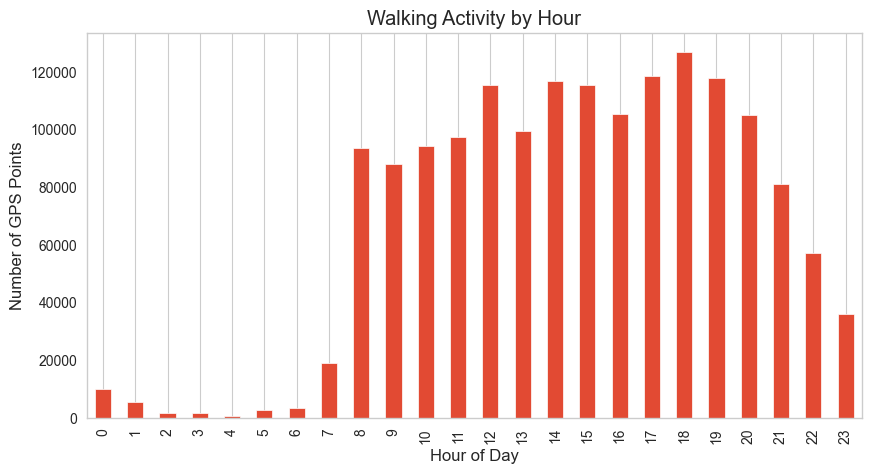

In [19]:
df['datetime'] = pd.to_datetime(df['datetime'])
df['hour'] = df['datetime'].dt.hour

df['datetime_beijing'] = df['datetime'] + pd.Timedelta(hours=8)
df['hour_beijing'] = df['datetime_beijing'].dt.hour

hour_counts = df['hour_beijing'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind='bar')

plt.xlabel("Hour of Day")
plt.ylabel("Number of GPS Points")
plt.title("Walking Activity by Hour")
plt.xticks(range(24))
plt.grid(axis='y')

plt.show()

In [21]:
beijing_bbox = {
    "lat_min": 39.4,
    "lat_max": 41.0,
    "lon_min": 115.7,
    "lon_max": 117.4
}
df_bj = df[
    (df['lat'] >= beijing_bbox["lat_min"]) &
    (df['lat'] <= beijing_bbox["lat_max"]) &
    (df['lon'] >= beijing_bbox["lon_min"]) &
    (df['lon'] <= beijing_bbox["lon_max"])
]

Number of unique  trips: 2184
Number of persons: 60

Transportation mode distribution:


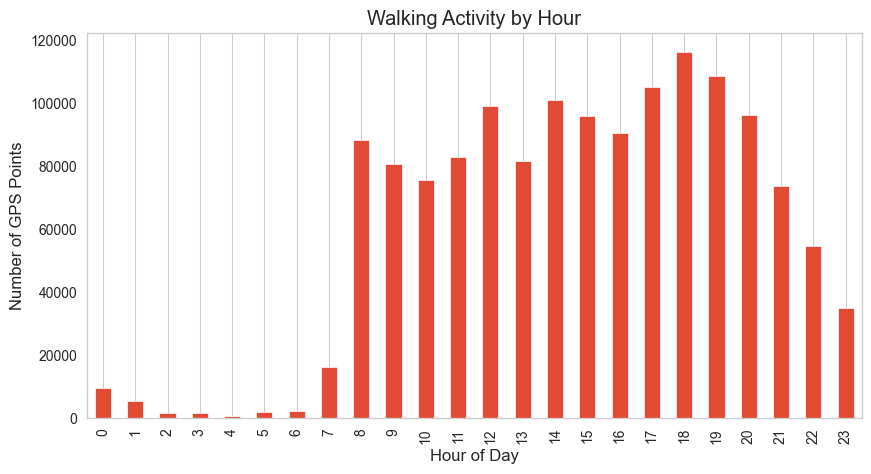

In [22]:
print(f"Number of unique  trips: {df_bj['trajectory_id'].nunique()}")
print(f"Number of persons: {df_bj['user_id'].nunique()}")
print("\nTransportation mode distribution:")


hour_counts = df_bj['hour_beijing'].value_counts().sort_index()

plt.figure(figsize=(10,5))
hour_counts.plot(kind='bar')

plt.xlabel("Hour of Day")
plt.ylabel("Number of GPS Points")
plt.title("Walking Activity by Hour")
plt.xticks(range(24))
plt.grid(axis='y')

plt.show()

In [23]:
def sampling_stats_df(df):

    # Ensure datetime type
    df = df.copy()

    df["datetime"] = pd.to_datetime(df["datetime"])

    # Sort correctly
    df = df.sort_values(
        ["trajectory_id", "datetime"]
    )

    # Compute dt within each trajectory
    df["dt"] = (
        df.groupby("trajectory_id")["datetime"]
        .diff()
        .dt.total_seconds()
    )

    # Remove invalid intervals
    valid_dt = df["dt"][
        (df["dt"] > 0) &
        (df["dt"] < 3600)
    ]

    print("\nSampling Interval Statistics")
    print("-" * 40)

    print(f"Total intervals : {len(valid_dt):,}")
    print(f"Total traces    : {df['trajectory_id'].nunique():,}")

    print("\nGlobal distribution:")
    print(f"  Mean   : {valid_dt.mean():.2f} s")
    print(f"  Median : {valid_dt.median():.2f} s")
    print(f"  Std    : {valid_dt.std():.2f} s")
    print(f"  Min    : {valid_dt.min():.2f} s")
    print(f"  Max    : {valid_dt.max():.2f} s")

    print("\nPercentiles:")

    for p in [1, 5, 10, 25, 50, 75, 90, 95, 99]:

        print(
            f"  p{p:>2}: "
            f"{np.percentile(valid_dt, p):.2f} s"
        )

    # Per-trajectory median dt
    traj_stats = (
        df.groupby("trajectory_id")["dt"]
        .median()
        .dropna()
    )

    print("\nPer-trajectory median interval:")
    print(f"  Mean median   : {traj_stats.mean():.2f} s")
    print(f"  Median median : {traj_stats.median():.2f} s")

    print("\nBucket distribution:")

    buckets = [
        (0, 1, "0–1s"),
        (1, 2, "1–2s"),
        (2, 5, "2–5s"),
        (5, 10, "5–10s"),
        (10, 30, "10–30s"),
        (30, 60, "30–60s"),
        (60, 300, "1–5min"),
        (300, 3600, ">5min"),
    ]

    for low, high, label in buckets:

        ratio = (
            ((valid_dt >= low) & (valid_dt < high))
            .mean()
        )

        print(f"  {label:<8}: {ratio*100:.1f}%")

    return df
sampling_stats_df(df_bj)


Sampling Interval Statistics
----------------------------------------
Total intervals : 1,119,681
Total traces    : 2,184

Global distribution:
  Mean   : 5.69 s
  Median : 2.00 s
  Std    : 65.26 s
  Min    : 1.00 s
  Max    : 3587.00 s

Percentiles:
  p 1: 1.00 s
  p 5: 1.00 s
  p10: 1.00 s
  p25: 2.00 s
  p50: 2.00 s
  p75: 2.00 s
  p90: 5.00 s
  p95: 5.00 s
  p99: 31.00 s

Per-trajectory median interval:
  Mean median   : 5.67 s
  Median median : 2.00 s

Bucket distribution:
  0–1s    : 0.0%
  1–2s    : 16.1%
  2–5s    : 66.6%
  5–10s   : 15.3%
  10–30s  : 1.0%
  30–60s  : 0.4%
  1–5min  : 0.4%
  >5min   : 0.2%


,lat,lon,zero,altitude,date_days,date,time,datetime,user_id,trajectory_id,transportation_mode,hour,datetime_beijing,hour_beijing,dt
734426,39.976233,116.330567,0,118.110236,39184.432813,2007-04-12,10:23:15,2007-04-12 10:23:15,161,20070412101853,walk,10,2007-04-12 18:23:15,18,NaN
734470,39.975850,116.330400,0,114.829396,39184.432928,2007-04-12,10:23:25,2007-04-12 10:23:25,161,20070412102325,walk,10,2007-04-12 18:23:25,18,NaN
734471,39.975983,116.330467,0,114.829396,39184.433762,2007-04-12,10:24:37,2007-04-12 10:24:37,161,20070412102325,walk,10,2007-04-12 18:24:37,18,72.0
734472,39.976100,116.330500,0,118.110236,39184.434062,2007-04-12,10:25:03,2007-04-12 10:25:03,161,20070412102325,walk,10,2007-04-12 18:25:03,18,26.0
734473,39.976233,116.330567,0,118.110236,39184.435012,2007-04-12,10:26:25,2007-04-12 10:26:25,161,20070412102325,walk,10,2007-04-12 18:26:25,18,82.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
732204,39.991615,116.330483,0,0.000000,40908.637350,2011-12-31,15:17:47,2011-12-31 15:17:47,102,20111231144437,walk,15,2011-12-31 23:17:47,23,5.0
732205,39.991630,116.330473,0,0.000000,40908.637407,2011-12-31,15:17:52,2011-12-31 15:17:52,102,20111231144437,walk,15,2011-12-31 23:17:52,23,5.0
732206,39.991642,116.330465,0,0.000000,40908.637465,2011-12-31,15:17:57,2011-12-31 15:17:57,102,20111231144437,walk,15,2011-12-31 23:17:57,23,5.0
732207,39.991670,116.330468,0,0.000000,40908.637523,2011-12-31,15:18:02,2011-12-31 15:18:02,102,20111231144437,walk,15,2011-12-31 23:18:02,23,5.0


In [26]:
from filter_walking_data import extract_points
EARTH_RADIUS = 6371000  # meters


def haversine(lat1, lon1, lat2, lon2):

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * EARTH_RADIUS * np.arcsin(np.sqrt(a))
def gpx_distance_stats(folder):

    trajectory_distances = []
    all_steps = []

    for file in os.listdir(folder):

        if not file.endswith(".gpx"):
            continue

        path = os.path.join(folder, file)

        try:

            points = extract_points(path)

            if len(points) < 2:
                continue

            total = 0

            for i in range(1, len(points)):

                lat1, lon1, _ = points[i - 1]
                lat2, lon2, _ = points[i]

                d = haversine(
                    lat1, lon1,
                    lat2, lon2
                )

                # optional spike rejection
                if d < 200:

                    total += d
                    all_steps.append(d)

            trajectory_distances.append(total)

        except Exception as e:
            print("ERROR:", file, e)

    traj = np.array(trajectory_distances)
    steps = np.array(all_steps)

    print("\nGPX Distance Statistics")
    print("-" * 40)

    print(f"Total traces : {len(traj):,}")

    print("\nTrajectory lengths:")
    print(f"  Mean   : {traj.mean()/1000:.2f} km")
    print(f"  Median : {np.median(traj)/1000:.2f} km")
    print(f"  Std    : {traj.std()/1000:.2f} km")
    print(f"  Max    : {traj.max()/1000:.2f} km")

    print("\nPercentiles:")

    for p in [5,10,25,50,75,90,95,99]:

        print(
            f"  p{p:>2}: "
            f"{np.percentile(traj,p)/1000:.2f} km"
        )

    print("\nStep distance distribution:")
    print(f"  Mean   : {steps.mean():.2f} m")
    print(f"  Median : {np.median(steps):.2f} m")
    print(f"  p95    : {np.percentile(steps,95):.2f} m")
    print(f"  Max    : {steps.max():.2f} m")
gpx_distance_stats("./paris_traces_walking")


GPX Distance Statistics
----------------------------------------
Total traces : 983

Trajectory lengths:
  Mean   : 1.14 km
  Median : 0.78 km
  Std    : 1.35 km
  Max    : 20.64 km

Percentiles:
  p 5: 0.09 km
  p10: 0.17 km
  p25: 0.38 km
  p50: 0.78 km
  p75: 1.57 km
  p90: 2.43 km
  p95: 3.14 km
  p99: 5.18 km

Step distance distribution:
  Mean   : 2.72 m
  Median : 1.40 m
  p95    : 10.72 m
  Max    : 199.92 m


In [5]:
from filter_walking_data import extract_points
EARTH_RADIUS = 6371000  # meters


def haversine(lat1, lon1, lat2, lon2):

    lat1, lon1, lat2, lon2 = map(
        np.radians,
        [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1)
        * np.cos(lat2)
        * np.sin(dlon / 2) ** 2
    )

    return 2 * EARTH_RADIUS * np.arcsin(np.sqrt(a))
def gpx_distance_stats(folder):

    trajectory_distances = []
    all_steps = []

    for file in os.listdir(folder):

        if not file.endswith(".gpx"):
            continue

        path = os.path.join(folder, file)

        try:

            points = extract_points(path)

            if len(points) < 2:
                continue

            total = 0

            for i in range(1, len(points)):

                lat1, lon1, _ = points[i - 1]
                lat2, lon2, _ = points[i]

                d = haversine(
                    lat1, lon1,
                    lat2, lon2
                )

                # optional spike rejection
                if d < 200:

                    total += d
                    all_steps.append(d)

            trajectory_distances.append(total)

        except Exception as e:
            print("ERROR:", file, e)

    traj = np.array(trajectory_distances)
    steps = np.array(all_steps)

    print("\nGPX Distance Statistics")
    print("-" * 40)

    print(f"Total traces : {len(traj):,}")

    print("\nTrajectory lengths:")
    print(f"  Mean   : {traj.mean()/1000:.2f} km")
    print(f"  Median : {np.median(traj)/1000:.2f} km")
    print(f"  Std    : {traj.std()/1000:.2f} km")
    print(f"  Max    : {traj.max()/1000:.2f} km")

    print("\nPercentiles:")

    for p in [5,10,25,50,75,90,95,99]:

        print(
            f"  p{p:>2}: "
            f"{np.percentile(traj,p)/1000:.2f} km"
        )

    print("\nStep distance distribution:")
    print(f"  Mean   : {steps.mean():.2f} m")
    print(f"  Median : {np.median(steps):.2f} m")
    print(f"  p95    : {np.percentile(steps,95):.2f} m")
    print(f"  Max    : {steps.max():.2f} m")
gpx_distance_stats("./londres_traces_walking")



GPX Distance Statistics
----------------------------------------
Total traces : 8,549

Trajectory lengths:
  Mean   : 1.33 km
  Median : 1.01 km
  Std    : 1.15 km
  Max    : 12.85 km

Percentiles:
  p 5: 0.14 km
  p10: 0.21 km
  p25: 0.46 km
  p50: 1.01 km
  p75: 1.87 km
  p90: 2.90 km
  p95: 3.56 km
  p99: 5.15 km

Step distance distribution:
  Mean   : 3.06 m
  Median : 1.49 m
  p95    : 10.82 m
  Max    : 199.72 m


In [4]:
gpx_distance_stats('./paris_traces_walking')


GPX Distance Statistics
----------------------------------------
Total traces : 983

Trajectory lengths:
  Mean   : 1.14 km
  Median : 0.78 km
  Std    : 1.35 km
  Max    : 20.64 km

Percentiles:
  p 5: 0.09 km
  p10: 0.17 km
  p25: 0.38 km
  p50: 0.78 km
  p75: 1.57 km
  p90: 2.43 km
  p95: 3.14 km
  p99: 5.18 km

Step distance distribution:
  Mean   : 2.72 m
  Median : 1.40 m
  p95    : 10.72 m
  Max    : 199.92 m


In [5]:
# =========================================================
# SAVE / LOAD OSM WALKING GRAPH
# =========================================================

import osmnx as ox

# =========================================================
# DOWNLOAD GRAPH ONCE
# =========================================================

print("Downloading London walking graph...")

G = ox.graph_from_place(
    "London, United Kingdom",
    network_type="walk",
    simplify=False
)

print("Graph loaded.")

# =========================================================
# SAVE GRAPH
# =========================================================

ox.save_graphml(
    G,
    filepath="london_walk.graphml"
)

print("Graph saved.")

Graph loaded.
Graph saved.


In [1]:
# =========================================================
# SAVE / LOAD OSM WALKING GRAPH
# =========================================================

import osmnx as ox

# =========================================================
# DOWNLOAD GRAPH ONCE
# =========================================================

print("Downloading paris walking graph...")

G = ox.graph_from_place(
    "Paris, France",
    network_type="walk",
    simplify=False
)

print("Graph loaded.")

# =========================================================
# SAVE GRAPH
# =========================================================

ox.save_graphml(
    G,
    filepath="paris_walk.graphml"
)

print("Graph saved.")

Graph loaded.
Graph saved.


In [ ]:
import osmnx as ox

print("Downloading beijing walking graph...")

G = ox.graph_from_place(
    "Beijing, China",
    network_type="walk",
    simplify=True
)

print("Graph loaded.")

ox.save_graphml(
    G,
    filepath="beijing_walk.graphml"
)

print("Graph saved.")

C:\Users\oussama.nair\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\osmnx\_overpass.py:271: UserWarning: This area is 11 times your configured Overpass max query area size. It will automatically be divided up into multiple sub-queries accordingly. This may take a long time.
  multi_poly_proj = utils_geo._consolidate_subdivide_geometry(poly_proj)


Graph loaded.
Graph saved.


In [ ]:


import os
import gpxpy
import pandas as pd
import osmnx as ox
import folium

# =========================================================
# PARAMETERS
# =========================================================

GPX_FOLDER = "londres_traces_walking"
N_TRAJ = 20

# =========================================================
# LOAD WALKING GRAPH
# =========================================================

print("Loading London walking graph...")
print("Loading saved graph...")

G = ox.load_graphml(
    "london_walk.graphml"
)

print("Graph loaded.")
print(f"Nodes: {len(G.nodes):,}")
print(f"Edges: {len(G.edges):,}")

# =========================================================
# GPX LOADER
# =========================================================

import xml.etree.ElementTree as ET
import pandas as pd

NS = {
    "gpx": "http://www.topografix.com/GPX/1/0"
}

def load_gpx(filepath):

    tree = ET.parse(filepath)

    root = tree.getroot()

    points = []

    for pt in root.findall(".//gpx:trkpt", NS):

        lat = pt.attrib["lat"]
        lon = pt.attrib["lon"]

        time_elem = pt.find("gpx:time", NS)

        timestamp = (
            time_elem.text
            if time_elem is not None
            else None
        )

        points.append({
            "lat": float(lat),
            "lon": float(lon),
            "datetime": timestamp
        })

    df = pd.DataFrame(points)

    if len(df) > 0:
        df["datetime"] = pd.to_datetime(df["datetime"])

    return df

# =========================================================
# VISUALIZATION
# =========================================================

def visualize(df, G, output_html):

    center_lat = df["lat"].mean()
    center_lon = df["lon"].mean()

    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=15
    )

    # -----------------------------------------------------
    # RAW TRAJECTORY
    # -----------------------------------------------------

    coords = list(zip(df["lat"], df["lon"]))

    folium.PolyLine(
        coords,
        color="red",
        weight=4,
        opacity=0.8,
        tooltip="Trajectory"
    ).add_to(m)

    # -----------------------------------------------------
    # MATCHED EDGES
    # -----------------------------------------------------

    unique_edges = df["matched_edge"].dropna().unique()

    for edge in unique_edges:

        u, v, key = edge

        edge_data = G.get_edge_data(u, v, key)

        if edge_data is None:
            continue

        geometry = edge_data.get("geometry", None)

        if geometry is None:
            continue

        edge_coords = [
            (lat, lon)
            for lon, lat in geometry.coords
        ]

        folium.PolyLine(
            edge_coords,
            color="green",
            weight=5,
            opacity=0.7,
            tooltip="Matched edge"
        ).add_to(m)

    m.save(output_html)

# =========================================================
# PROCESS TRAJECTORIES
# =========================================================

all_files = sorted([
    f for f in os.listdir(GPX_FOLDER)
    if f.endswith(".gpx")
])

print(f"\nFound {len(all_files)} GPX files")

processed = 0

for file in all_files:

    if processed >= N_TRAJ:
        break

    print(f"\nProcessing {file}")

    path = os.path.join(GPX_FOLDER, file)

    # -----------------------------------------------------
    # LOAD GPX
    # -----------------------------------------------------

    df = load_gpx(path)

    print(f"  points: {len(df)}")

    if len(df) < 2:
        print("  skipped")
        continue

    # -----------------------------------------------------
    # MAP MATCH
    # -----------------------------------------------------

    edges = ox.distance.nearest_edges(
        G,
        X=df["lon"],
        Y=df["lat"]
    )

    df["matched_edge"] = list(edges)

    # -----------------------------------------------------
    # SAVE VISUALIZATION
    # -----------------------------------------------------

    output_html = f"matched_{processed}.html"

    visualize(df, G, output_html)

    print(f"  saved: {output_html}")

    processed += 1

print("\nDONE.")

Loading London walking graph...
Graph loaded.
Nodes: 509,247
Edges: 1,313,672

Found 8549 GPX files

Processing trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f.gpx
  points: 575
  saved: matched_0.html

Processing trace_00064f47-3bf5-44ce-9852-df98d1e86078.gpx
  points: 50
  saved: matched_1.html

Processing trace_0008688d-e853-4d41-b7bb-3cbf0e9b33af.gpx
  points: 95
  saved: matched_2.html

Processing trace_000fa458-e418-447e-9cf2-77200e1ba07e.gpx
  points: 92
  saved: matched_3.html

Processing trace_0011972f-1a4d-448c-a51b-00c85fb7964b.gpx
  points: 1920
  saved: matched_4.html

Processing trace_00192c2a-c040-4e29-a71e-d0dd1ece9ebe.gpx
  points: 995
  saved: matched_5.html

Processing trace_0023ab00-dd38-42cc-a9a9-1e84143250f5.gpx
  points: 701
  saved: matched_6.html

Processing trace_00245b2f-3807-4169-9f92-edcf893781bb.gpx
  points: 1587
  saved: matched_7.html

Processing trace_004131c3-615a-4942-b53e-f02184ff0190.gpx
  points: 71
  saved: matched_8.html

Processing trace_00420742-57

In [1]:


import os
import xml.etree.ElementTree as ET
import pandas as pd
import osmnx as ox
import folium

from leuvenmapmatching.map.inmem import InMemMap
from leuvenmapmatching.matcher.distance import DistanceMatcher

def smooth_trajectory(traj, window=5):

    df = pd.DataFrame(traj)

    df["lat"] = (
        df["lat"]
        .rolling(
            window=window,
            center=True,
            min_periods=1
        )
        .mean()
    )

    df["lon"] = (
        df["lon"]
        .rolling(
            window=window,
            center=True,
            min_periods=1
        )
        .mean()
    )

    return df.to_dict("records")
# =========================================================
# PARAMETERS
# =========================================================

GPX_FOLDER = "londres_traces_walking"

N_TRAJ = 20

# =========================================================
# LOAD OSM WALKING GRAPH
# =========================================================

print("Loading London walking graph...")

print("Loading saved graph...")

G = ox.load_graphml(
    "london_walk.graphml"
)

print("Graph loaded.")
print(f"Nodes: {len(G.nodes):,}")
print(f"Edges: {len(G.edges):,}")

# =========================================================
# CONVERT OSMNX GRAPH → LEUVEN GRAPH
# =========================================================

print("\nConverting graph for HMM matcher...")

map_con = InMemMap(
    "paris_walk",
    use_latlon=True,
    use_rtree=False,
    index_edges=True
)

# ---------------------------------------------------------
# ADD NODES
# ---------------------------------------------------------

for node_id, data in G.nodes(data=True):

    map_con.add_node(
        node_id,
        (data["y"], data["x"])
    )

# ---------------------------------------------------------
# ADD EDGES
# ---------------------------------------------------------

for u, v in G.edges():

    map_con.add_edge(u, v)

print("Graph converted.")

# =========================================================
# HMM MATCHER
# =========================================================

matcher = DistanceMatcher(
    map_con,

    max_dist=50,          # GPS search radius
    max_dist_init=50,

    obs_noise=5,         # GPS noise
    obs_noise_ne=5,

    dist_noise=10,

    non_emitting_length_factor=0.5,

    max_lattice_width=20
)

# =========================================================
# GPX LOADER
# =========================================================

NS = {
    "gpx": "http://www.topografix.com/GPX/1/0"
}

def load_gpx(filepath):

    tree = ET.parse(filepath)

    root = tree.getroot()

    points = []

    for pt in root.findall(".//gpx:trkpt", NS):

        lat = float(pt.attrib["lat"]) 
        lon = float(pt.attrib["lon"])

        time_elem = pt.find("gpx:time", NS)

        timestamp = (
            time_elem.text
            if time_elem is not None
            else None
        )

        points.append({
            "lat": lat,
            "lon": lon,
            "datetime": timestamp
        })

    df = pd.DataFrame(points)

    if len(df) > 0:
        df["datetime"] = pd.to_datetime(df["datetime"])

    return df

# =========================================================
# VISUALIZATION
# =========================================================

def visualize(df, states, G, output_html):

    center_lat = df["lat"].mean()
    center_lon = df["lon"].mean()

    m = folium.Map(
        location=[center_lat, center_lon],
        zoom_start=15
    )

    # =====================================================
    # RAW GPS TRAJECTORY
    # =====================================================

    gps_coords = list(zip(
        df["lat"],
        df["lon"]
    ))

    folium.PolyLine(
        gps_coords,
        color="red",
        weight=3,
        opacity=0.8,
        tooltip="Raw GPS"
    ).add_to(m)

    # =====================================================
    # MATCHED TRAJECTORY
    # =====================================================

    matched_coords = []

    for state in states:

        try:

            # Leuven states are often tuples
            node = state[0] if isinstance(state, tuple) else state

            if node in G.nodes:

                lat = G.nodes[node]["y"]
                lon = G.nodes[node]["x"]

                matched_coords.append((lat, lon))

        except:
            continue

    print(f"Matched coordinates: {len(matched_coords)}")

    # =====================================================
    # DRAW MATCHED PATH
    # =====================================================

    if len(matched_coords) > 1:

        folium.PolyLine(
            matched_coords,
            color="blue",
            weight=5,
            opacity=0.9,
            tooltip="HMM matched"
        ).add_to(m)

        # Add blue markers for debugging
        for lat, lon in matched_coords:

            folium.CircleMarker(
                [lat, lon],
                radius=2,
                color="blue",
                fill=True
            ).add_to(m)

    else:

        print("No valid matched coordinates.")

    # =====================================================
    # SAVE
    # =====================================================

    m.save(output_html)
# =========================================================
# PROCESS GPX FILES
# =========================================================

all_files = sorted([
    f for f in os.listdir(GPX_FOLDER)
    if f.endswith(".gpx")
])

print(f"\nFound {len(all_files)} GPX files")

processed = 0

for file in all_files:

    if processed >= N_TRAJ:
        break

    print(f"\nProcessing {file}")

    path = os.path.join(GPX_FOLDER, file)

    # -----------------------------------------------------
    # LOAD GPX
    # -----------------------------------------------------

    df = load_gpx(path)

    print(f"  points: {len(df)}")

    if len(df) < 10:
        print("  skipped")
        continue
    # -----------------------------------------------------
# SMOOTH GPS TRAJECTORY
# -----------------------------------------------------

    window = 5

    df["lat_smooth"] = (
        df["lat"]
        .rolling(
            window=window,
            center=True,
            min_periods=1
        )
        .mean()
    )

    df["lon_smooth"] = (
        df["lon"]
        .rolling(
            window=window,
            center=True,
            min_periods=1
        )
        .mean()
)
    # -----------------------------------------------------
    # GPS OBSERVATIONS
    # -----------------------------------------------------

    path_points = list(zip(
        df["lat_smooth"],
        df["lon_smooth"]
    ))

    # -----------------------------------------------------
    # HMM MAP MATCHING
    # -----------------------------------------------------

    try:

        states, _ = matcher.match(path_points)

    except Exception as e:

        print(f"  matching failed: {e}")
        continue

    print(f"  matched states: {len(states)}")

    if len(states) < 2:
        print("  insufficient matched path")
        continue

    # -----------------------------------------------------
    # VISUALIZE
    # -----------------------------------------------------

    output_html = f"hmm_match_{processed}.html"

    visualize(
        df,
        states,
        G,
        output_html
    )

    print(f"  saved: {output_html}")

    processed += 1

print("\nDONE.")

Loading London walking graph...
Loading saved graph...
Graph loaded.
Nodes: 1,646,373
Edges: 3,587,896

Converting graph for HMM matcher...


Searching closeby nodes with linear search, use an index and set max_dist


Graph converted.

Found 8549 GPX files

Processing trace_000548ef-7b4d-4dc2-9a53-3dc09d32016f.gpx
  points: 575


Searching closeby nodes with linear search, use an index and set max_dist


  matched states: 580
Matched coordinates: 580
  saved: hmm_match_0.html

Processing trace_00064f47-3bf5-44ce-9852-df98d1e86078.gpx
  points: 50


...

  saved: hmm_match_16.html

Processing trace_00f82b47-dd1c-441a-9b89-385c982112a3.gpx
  points: 147


Searching closeby nodes with linear search, use an index and set max_dist


  matched states: 147
Matched coordinates: 147
  saved: hmm_match_17.html

Processing trace_00f89b85-fa5d-4fff-9528-e5791c902d03.gpx
  points: 492


Searching closeby nodes with linear search, use an index and set max_dist


  matched states: 492
Matched coordinates: 492
  saved: hmm_match_18.html

Processing trace_01045e57-989f-4c6e-962b-b0d8d8d3a6d8.gpx
  points: 68
  matched states: 68
Matched coordinates: 68
  saved: hmm_match_19.html

DONE.


Loading London walking graph...
  Nodes: 260,315  Edges: 587,428
Building Leuven InMemMap...
  Leuven graph ready.

Found 983 GPX files

Processed: 582 matched, 401 failed, 0 skipped

========== SPEED STATISTICS ==========

  [Before map matching]
    Segments       : 263,864
    Total dist     : 827453.1 m
    Mean speed     : 1.248 m/s
    Median speed   : 1.149 m/s
    Std speed      : 3.423 m/s
    p 5            : 0.021 m/s
    p25            : 0.589 m/s
    p50            : 1.149 m/s
    p75            : 1.567 m/s
    p95            : 2.403 m/s

  [After  map matching]
    Segments       : 18,408
    Total dist     : 129798.0 m
    Mean speed     : 1.149 m/s
    Median speed   : 0.766 m/s
    Std speed      : 1.055 m/s
    p 5            : 0.083 m/s
    p25            : 0.295 m/s
    p50            : 0.766 m/s
    p75            : 1.788 m/s
    p95            : 3.399 m/s

  Traces before : 983
  Traces after  : 582


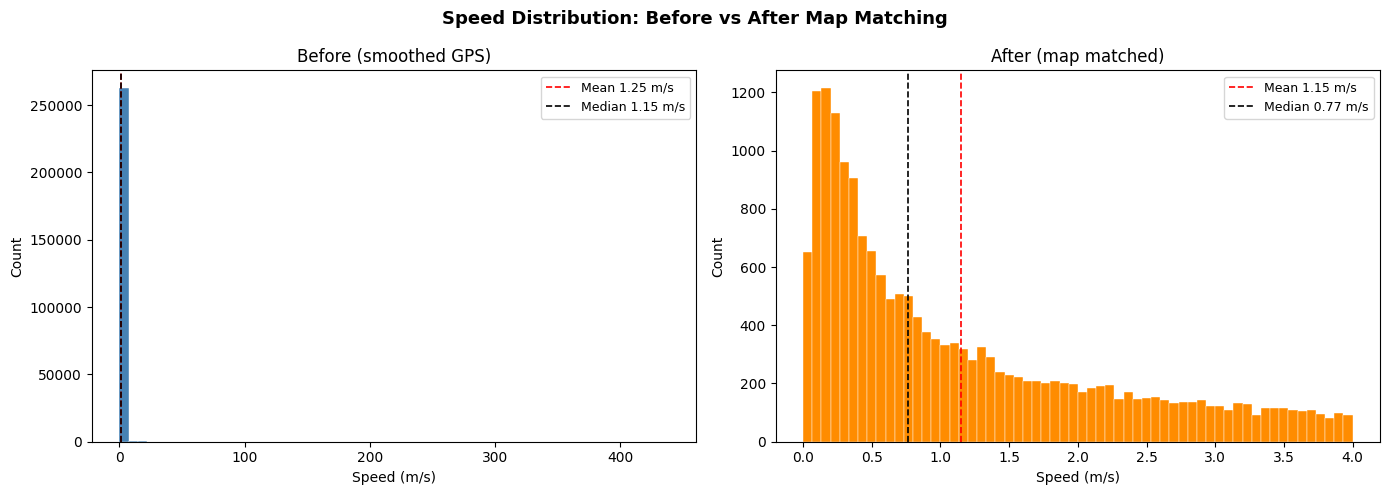

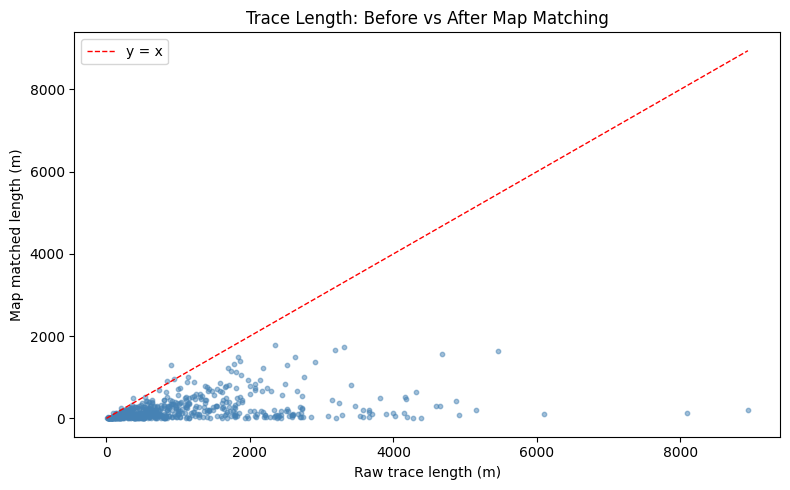


Building map...
Map saved → map_matched_all.html


In [2]:
import os
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import osmnx as ox
import folium
import networkx as nx
import matplotlib.pyplot as plt
from collections import defaultdict

from leuvenmapmatching.map.inmem import InMemMap
from leuvenmapmatching.matcher.distance import DistanceMatcher

# =========================================================
# PARAMETERS
# =========================================================

GPX_FOLDER   = "paris_traces_walking"
GRAPH_PATH   = "paris_walk.graphml"
OUTPUT_MAP   = "map_matched_all.html"
ROLLING_WIN  = 5
MIN_POINTS   = 10

NS = {"gpx": "http://www.topografix.com/GPX/1/0"}

# =========================================================
# LOAD GRAPH
# =========================================================

print("Loading London walking graph...")
G = ox.load_graphml(GRAPH_PATH)
print(f"  Nodes: {len(G.nodes):,}  Edges: {len(G.edges):,}")

# =========================================================
# BUILD LEUVEN GRAPH
# =========================================================

print("Building Leuven InMemMap...")
map_con = InMemMap("london_walk", use_latlon=True, use_rtree=True, index_edges=True)

for node_id, data in G.nodes(data=True):
    map_con.add_node(node_id, (data["y"], data["x"]))

for u, v, data in G.edges(data=True):
    map_con.add_edge(u, v)
    if "geometry" in data:
        coords = list(data["geometry"].coords)
        map_con.add_edge_geometry(u, v, [(lat, lon) for lon, lat in coords])

map_con.purge()
print("  Leuven graph ready.")

# =========================================================
# MATCHER
# =========================================================

matcher = DistanceMatcher(
    map_con,
    max_dist=30,
    max_dist_init=30,
    obs_noise=10,
    obs_noise_ne=10,
    dist_noise=5,
    non_emitting_length_factor=0.75,
    max_lattice_width=10
)

# =========================================================
# HELPERS
# =========================================================

def load_gpx(filepath):
    tree = ET.parse(filepath)
    root = tree.getroot()
    points = []
    for pt in root.findall(".//gpx:trkpt", NS):
        try:
            lat = float(pt.attrib["lat"])
            lon = float(pt.attrib["lon"])
            time_elem = pt.find("gpx:time", NS)
            t = pd.to_datetime(time_elem.text) if time_elem is not None else None
            points.append({"lat": lat, "lon": lon, "datetime": t})
        except (ValueError, KeyError):
            continue
    return pd.DataFrame(points)


def smooth(df, window=ROLLING_WIN):
    df["lat_smooth"] = df["lat"].rolling(window, center=True, min_periods=1).mean()
    df["lon_smooth"] = df["lon"].rolling(window, center=True, min_periods=1).mean()
    return df


def haversine(lat1, lon1, lat2, lon2):
    R = 6_371_000
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlam = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1)*np.cos(phi2)*np.sin(dlam/2)**2
    return 2 * R * np.arctan2(np.sqrt(a), np.sqrt(1 - a))


def raw_stats(df):
    """Compute per-point speed and distance on raw/smoothed trace."""
    records = []
    for i in range(1, len(df)):
        dt = (df["datetime"].iloc[i] - df["datetime"].iloc[i-1]).total_seconds()
        if dt <= 0:
            continue
        dist = haversine(
            df["lat_smooth"].iloc[i-1], df["lon_smooth"].iloc[i-1],
            df["lat_smooth"].iloc[i],   df["lon_smooth"].iloc[i]
        )
        records.append({"dist_m": dist, "dt_s": dt, "speed_mps": dist / dt})
    return pd.DataFrame(records)


def get_edge_length(G, u, v):
    data = G.get_edge_data(u, v)
    if data is None:
        return None
    if isinstance(data, dict) and 0 in data:
        return data[0].get("length")
    return data.get("length")


def matched_stats(df, states):
    """Compute per-step speed and distance on map-matched trace."""
    nodes = []
    for state in states:
        node = state[0] if isinstance(state, tuple) else state
        if node in G.nodes:
            nodes.append(node)

    if len(nodes) < 2:
        return None, []

    n = min(len(nodes), len(df))
    timestamps = df["datetime"].iloc[:n].values
    matched_coords = [(G.nodes[nd]["y"], G.nodes[nd]["x"]) for nd in nodes[:n]]

    records = []
    for i in range(1, n):
        u, v = nodes[i-1], nodes[i]
        if u == v:
            continue
        length = get_edge_length(G, u, v)
        if length is None:
            try:
                length = nx.shortest_path_length(G, u, v, weight="length")
            except nx.NetworkXNoPath:
                continue
        dt = (pd.Timestamp(timestamps[i]) - pd.Timestamp(timestamps[i-1])).total_seconds()
        if dt <= 0:
            continue
        speed = length / dt
        if speed > 4.0:
            continue
        records.append({"dist_m": length, "dt_s": dt, "speed_mps": speed})

    return pd.DataFrame(records) if records else None, matched_coords


def print_stats(label, df_stats):
    if df_stats is None or len(df_stats) == 0:
        print(f"  {label}: no data")
        return
    s = df_stats["speed_mps"]
    d = df_stats["dist_m"]
    print(f"\n  [{label}]")
    print(f"    Segments       : {len(df_stats):,}")
    print(f"    Total dist     : {d.sum():.1f} m")
    print(f"    Mean speed     : {s.mean():.3f} m/s")
    print(f"    Median speed   : {s.median():.3f} m/s")
    print(f"    Std speed      : {s.std():.3f} m/s")
    for p in [5, 25, 50, 75, 95]:
        print(f"    p{p:>2}            : {s.quantile(p/100):.3f} m/s")


# =========================================================
# PROCESS ALL TRACES
# =========================================================

all_files = sorted([f for f in os.listdir(GPX_FOLDER) if f.endswith(".gpx")])
print(f"\nFound {len(all_files)} GPX files")

all_raw_stats      = []
all_matched_stats  = []
all_raw_coords     = []   # for map
all_matched_coords = []   # for map

success = failed = skipped = 0

for file in all_files:
    path = os.path.join(GPX_FOLDER, file)

    try:
        df = load_gpx(path)

        if len(df) < MIN_POINTS or df["datetime"].isna().any():
            skipped += 1
            continue

        df = smooth(df)

        # ── Raw stats ──────────────────────────────────────
        df_raw = raw_stats(df)
        if df_raw is not None and len(df_raw) > 0:
            df_raw["file"] = file
            all_raw_stats.append(df_raw)
            all_raw_coords.append(list(zip(df["lat_smooth"], df["lon_smooth"])))

        # ── Map matching ───────────────────────────────────
        path_points = list(zip(df["lat_smooth"], df["lon_smooth"]))
        states, _ = matcher.match(path_points)

        if len(states) < 2:
            failed += 1
            continue

        df_matched, coords = matched_stats(df, states)

        if df_matched is not None and len(df_matched) > 0:
            df_matched["file"] = file
            all_matched_stats.append(df_matched)
            all_matched_coords.append(coords)
            success += 1
        else:
            failed += 1

    except Exception as e:
        print(f"  [ERROR] {file}: {e}")
        failed += 1

print(f"\nProcessed: {success} matched, {failed} failed, {skipped} skipped")

# =========================================================
# AGGREGATE STATS
# =========================================================

df_raw_all     = pd.concat(all_raw_stats,     ignore_index=True) if all_raw_stats     else None
df_matched_all = pd.concat(all_matched_stats, ignore_index=True) if all_matched_stats else None

print("\n========== SPEED STATISTICS ==========")
print_stats("Before map matching", df_raw_all)
print_stats("After  map matching", df_matched_all)

if df_raw_all is not None:
    print(f"\n  Traces before : {df_raw_all['file'].nunique()}")
if df_matched_all is not None:
    print(f"  Traces after  : {df_matched_all['file'].nunique()}")

# =========================================================
# SPEED DISTRIBUTION PLOT
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Speed Distribution: Before vs After Map Matching", fontsize=13, fontweight="bold")

for ax, df_s, label, color in [
    (axes[0], df_raw_all,     "Before (smoothed GPS)", "steelblue"),
    (axes[1], df_matched_all, "After (map matched)",   "darkorange"),
]:
    if df_s is None:
        continue
    speeds = df_s["speed_mps"]
    ax.hist(speeds, bins=60, color=color, edgecolor="white", linewidth=0.3)
    ax.axvline(speeds.mean(),   color="red",   linestyle="--", linewidth=1.2,
               label=f"Mean {speeds.mean():.2f} m/s")
    ax.axvline(speeds.median(), color="black", linestyle="--", linewidth=1.2,
               label=f"Median {speeds.median():.2f} m/s")
    ax.set_title(label)
    ax.set_xlabel("Speed (m/s)")
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig("speed_distribution_comparison.png", dpi=150)
plt.show()

# =========================================================
# TRACE LENGTH COMPARISON PLOT
# =========================================================

if df_raw_all is not None and df_matched_all is not None:
    raw_lengths     = df_raw_all.groupby("file")["dist_m"].sum()
    matched_lengths = df_matched_all.groupby("file")["dist_m"].sum()

    common = raw_lengths.index.intersection(matched_lengths.index)
    raw_lengths     = raw_lengths[common]
    matched_lengths = matched_lengths[common]

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.scatter(raw_lengths, matched_lengths, alpha=0.5, s=10, color="steelblue")
    max_val = max(raw_lengths.max(), matched_lengths.max())
    ax.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="y = x")
    ax.set_xlabel("Raw trace length (m)")
    ax.set_ylabel("Map matched length (m)")
    ax.set_title("Trace Length: Before vs After Map Matching")
    ax.legend()
    plt.tight_layout()
    plt.savefig("length_comparison.png", dpi=150)
    plt.show()

# =========================================================
# MAP
# =========================================================

print("\nBuilding map...")
m = folium.Map(location=[51.5, -0.12], zoom_start=12)

# Raw traces (red, thin)
for coords in all_raw_coords:
    if len(coords) > 1:
        folium.PolyLine(
            coords,
            color="red",
            weight=1.5,
            opacity=0.4,
            tooltip="Raw GPS"
        ).add_to(m)

# Matched traces (blue, thicker)
for coords in all_matched_coords:
    if len(coords) > 1:
        folium.PolyLine(
            coords,
            color="blue",
            weight=3,
            opacity=0.6,
            tooltip="Map matched"
        ).add_to(m)

# Legend
legend_html = """
<div style="position: fixed; bottom: 30px; left: 30px; z-index: 1000;
            background: white; padding: 10px 16px; border-radius: 8px;
            box-shadow: 2px 2px 6px rgba(0,0,0,0.3); font-size: 13px;">
    <b>Traces</b><br>
    <span style="color:red">&#9644;</span> Raw GPS<br>
    <span style="color:blue">&#9644;</span> Map matched
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))
m.save(OUTPUT_MAP)
print(f"Map saved → {OUTPUT_MAP}")

In [2]:
print(type(states[0]))
print(states[:10])

<class 'tuple'>
[(28829190, 28829191), (28829190, 28829191), (28829190, 28829191), (28829190, 28829191), (28829190, 28829191), (28829190, 28829191), (28829190, 28829191), (28829190, 28829191), (28829190, 28829191), (28829190, 28829191)]


London

In [2]:
import os
import osmnx as ox
import networkx as nx

G = ox.load_graphml(
    "london_walk.graphml"
)

print(
    len(G.nodes),
    len(G.edges)
)


509247 1313672


In [3]:
from leuvenmapmatching.map.inmem import InMemMap

map_con = InMemMap(
    "london",
    use_latlon=True,
    index_edges=True
)

for node, data in G.nodes(data=True):

    map_con.add_node(
        node,
        (
            data["y"],
            data["x"]
        )
    )

for u, v in G.edges():

    map_con.add_edge(
        u,
        v
    )

In [ ]:
from leuvenmapmatching.matcher.distance import DistanceMatcher

matcher = DistanceMatcher(
    map_con,
    max_dist=30,
    obs_noise=15,
    min_prob_norm=0.001,


)

In [5]:
import xml.etree.ElementTree as ET
import pandas as pd

NS = {
    "gpx":
    "http://www.topografix.com/GPX/1/0"
}

def load_gpx(path):

    tree = ET.parse(path)

    root = tree.getroot()

    pts = []

    for p in root.findall(
        ".//gpx:trkpt",
        NS
    ):

        t = p.find(
            "gpx:time",
            NS
        )

        pts.append({

            "lat":
            float(
                p.attrib["lat"]
            ),

            "lon":
            float(
                p.attrib["lon"]
            ),

            "datetime":
            pd.to_datetime(
                t.text
            )

        })

    return pts

In [6]:
def project_trajectory(traj):

    lats = [
        p["lat"]
        for p in traj
    ]

    lons = [
        p["lon"]
        for p in traj
    ]

    edges = ox.distance.nearest_edges(
        G,
        X=lons,
        Y=lats
    )

    projected = []

    for edge, p in zip(
        edges,
        traj
    ):

        u, v, k = edge

        y1 = G.nodes[u]["y"]
        x1 = G.nodes[u]["x"]

        y2 = G.nodes[v]["y"]
        x2 = G.nodes[v]["x"]

        projected.append({

            "lat":
            (y1+y2)/2,

            "lon":
            (x1+x2)/2,

            "datetime":
            p["datetime"]

        })

    return projected

In [7]:
def hmm_match(traj):

    gps = [

        (
            p["lat"],
            p["lon"]
        )

        for p in traj

    ]

    try:

        states, _ = matcher.match(
            gps
        )

    except:

        return None

    if len(states) < 2:

        return None

    matched = []

    n = min(
        len(states),
        len(traj)
    )

    for i in range(n):

        node = states[i]

        lat, lon = (
            map_con.node_coordinates(
                node
            )
        )

        matched.append({

            "lat": lat,

            "lon": lon,

            "datetime":
            traj[i]["datetime"]

        })

    return matched

In [8]:
GPX_FOLDER = (
    "londres_traces_walking"
)

raw_trajectories = []

proj_trajectories = []

hmm_trajectories = []

failed_hmm = 0

files = [

    f

    for f in os.listdir(
        GPX_FOLDER
    )

    if f.endswith(".gpx")

]

for i, file in enumerate(files):

    if i % 100 == 0:

        print(
            i,
            "/",
            len(files)
        )

    try:

        traj = load_gpx(

            os.path.join(
                GPX_FOLDER,
                file
            )

        )

        if len(traj) < 20:
            continue

        raw_trajectories.append(
            traj
        )

        proj_trajectories.append(

            project_trajectory(
                traj
            )

        )

        hmm_traj = hmm_match(
            traj
        )

        if hmm_traj is None:

            failed_hmm += 1

            continue

        hmm_trajectories.append(
            hmm_traj
        )

    except Exception:

        continue

0 / 8549


Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear se

100 / 8549


Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear se

200 / 8549


...

Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear se

8400 / 8549


Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear se

8500 / 8549


Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear search, use an index and set max_dist
Searching closeby nodes with linear se

In [ ]:
import numpy as np
import pandas as pd
from geopy.distance import geodesic
from scipy.stats import circstd
def bearing(lat1, lon1, lat2, lon2):

    lat1 = np.radians(lat1)
    lat2 = np.radians(lat2)

    dlon = np.radians(lon2 - lon1)

    x = np.sin(dlon) * np.cos(lat2)

    y = (
        np.cos(lat1)*np.sin(lat2)
        -
        np.sin(lat1)*np.cos(lat2)*np.cos(dlon)
    )

    b = np.degrees(
        np.arctan2(x, y)
    )

    return (b + 360) % 360
def trajectory_metrics(traj):

    if len(traj) < 3:
        return None

    length = 0

    speeds = []
    headings = []

    for i in range(1, len(traj)):

        p1 = traj[i-1]
        p2 = traj[i]

        d = geodesic(
            (p1["lat"], p1["lon"]),
            (p2["lat"], p2["lon"])
        ).meters

        length += d

        headings.append(
            bearing(
                p1["lat"],
                p1["lon"],
                p2["lat"],
                p2["lon"]
            )
        )

        if (
            "datetime" in p1
            and
            "datetime" in p2
        ):

            dt = (
                p2["datetime"]
                -
                p1["datetime"]
            ).total_seconds()

            if dt > 0:

                speeds.append(
                    d / dt
                )

    heading_changes = []

    for i in range(1, len(headings)):

        delta = abs(
            headings[i]
            -
            headings[i-1]
        )

        delta = min(
            delta,
            360 - delta
        )

        heading_changes.append(
            delta
        )

    turnaround_count = np.sum(
        np.array(
            heading_changes
        ) > 150
    )

    return {

        "length_m":
            length,

        "mean_speed":
            np.nanmean(speeds)
            if len(speeds)
            else np.nan,

        "median_speed":
            np.nanmedian(speeds)
            if len(speeds)
            else np.nan,

        "p95_speed":
            np.nanpercentile(
                speeds,
                95
            )
            if len(speeds)
            else np.nan,

        "heading_std":
            np.std(
                heading_changes
            )
            if len(heading_changes)
            else np.nan,

        "turnarounds":
            turnaround_count
    }


In [10]:
raw_metrics = []
proj_metrics = []
hmm_metrics = []

for traj in raw_trajectories:

    m = trajectory_metrics(traj)

    if m:
        raw_metrics.append(m)

for traj in proj_trajectories:

    m = trajectory_metrics(traj)

    if m:
        proj_metrics.append(m)

for traj in hmm_trajectories:

    m = trajectory_metrics(traj)

    if m:
        hmm_metrics.append(m)

raw_df = pd.DataFrame(raw_metrics)
proj_df = pd.DataFrame(proj_metrics)
hmm_df = pd.DataFrame(hmm_metrics)

In [11]:
summary = pd.DataFrame({

    "Raw":
        raw_df.mean(),

    "Projection":
        proj_df.mean(),

    "HMM":
        hmm_df.mean()

})

print(
    summary.round(2)
)

                  Raw  Projection  HMM
length_m      1478.21     1645.47  NaN
mean_speed       1.27        1.44  NaN
median_speed     1.29        0.02  NaN
p95_speed        2.00        4.97  NaN
heading_std     25.92       27.63  NaN
turnarounds      9.58        6.56  NaN


KeyError: 'mean_speed'

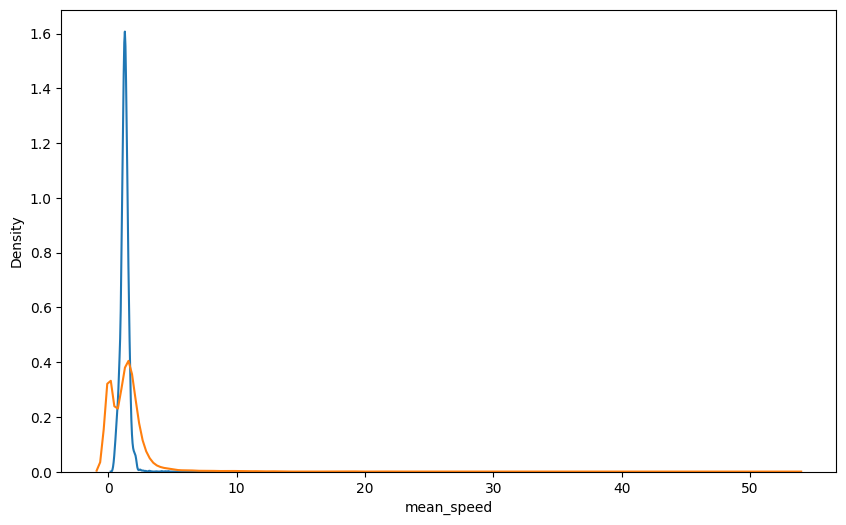

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

sns.kdeplot(
    raw_df["mean_speed"],
    label="Raw"
)

sns.kdeplot(
    proj_df["mean_speed"],
    label="Projection"
)

sns.kdeplot(
    hmm_df["mean_speed"],
    label="HMM"
)

plt.xlabel("Mean speed (m/s)")
plt.ylabel("Density")
plt.legend()
plt.show()

In [ ]:
ratios_proj = (
    proj_df["length_m"].values
    /
    raw_df["length_m"].values
)

ratios_hmm = (
    hmm_df["length_m"].values
    /
    raw_df["length_m"].values
)

plt.figure(figsize=(8,5))

plt.boxplot(
    [ratios_proj, ratios_hmm],
    labels=[
        "Projection",
        "HMM"
    ]
)

plt.axhline(
    1,
    color="red",
    linestyle="--"
)

plt.ylabel(
    "Length ratio vs raw"
)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot([

    raw_df["heading_std"],

    proj_df["heading_std"],

    hmm_df["heading_std"]

],

labels=[

    "Raw",

    "Projection",

    "HMM"

])

plt.ylabel(
    "Heading change std"
)

plt.show()

In [ ]:
plt.figure(figsize=(8,5))

plt.boxplot([

    raw_df["turnarounds"],

    proj_df["turnarounds"],

    hmm_df["turnarounds"]

],

labels=[

    "Raw",

    "Projection",

    "HMM"

])

plt.ylabel(
    "Turnarounds per trajectory"
)

plt.show()

In [ ]:
import folium

m = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=11,
    tiles="CartoDB positron"
)

for raw_traj, proj_traj in zip(
    raw_trajectories,
    proj_trajectories
):

    raw_coords = [
        (p["lat"], p["lon"])
        for p in raw_traj
    ]

    proj_coords = [
        (p["lat"], p["lon"])
        for p in proj_traj
    ]

    if len(raw_coords) > 1:

        folium.PolyLine(
            raw_coords,
            color="red",
            weight=1,
            opacity=0.05
        ).add_to(m)

    if len(proj_coords) > 1:

        folium.PolyLine(
            proj_coords,
            color="blue",
            weight=1,
            opacity=0.05
        ).add_to(m)

m.save("raw_vs_projection.html")
m

In [ ]:
import folium

m = folium.Map(
    location=[51.5074, -0.1278],
    zoom_start=11,
    tiles="CartoDB positron"
)

for raw_traj, hmm_traj in zip(
    raw_trajectories,
    hmm_trajectories
):

    raw_coords = [
        (p["lat"], p["lon"])
        for p in raw_traj
    ]

    hmm_coords = [
        (p["lat"], p["lon"])
        for p in hmm_traj
    ]

    if len(raw_coords) > 1:

        folium.PolyLine(
            raw_coords,
            color="red",
            weight=1,
            opacity=0.05
        ).add_to(m)

    if len(hmm_coords) > 1:

        folium.PolyLine(
            hmm_coords,
            color="green",
            weight=1,
            opacity=0.05
        ).add_to(m)

m.save("raw_vs_hmm.html")
m

Paris
